### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Maiccol Zurita

**Fecha:** 11/04/2026

## **NUESTRA PRIMERA RED NEURONAL: MNIST DATASET**

In [ ]:
packageName = "requests"
!pip install {packageName}


In [47]:
!pip freeze

absl-py==2.4.0
anyio @ file:///C:/Users/task_177313443047375/croot/anyio_1773134510930/work
argon2-cffi @ file:///C:/Users/task_176606717499708/croot/argon2-cffi_1766067891508/work
argon2-cffi-bindings @ file:///C:/miniconda3/conda-bld/argon2-cffi-bindings_1757925023673/work
asttokens @ file:///C:/Users/task_177313515777345/croot/asttokens_1773135664785/work
astunparse==1.6.3
async-lru @ file:///C:/miniconda3/conda-bld/async-lru_1761121577604/work
attrs @ file:///C:/miniconda3/conda-bld/attrs_1762356899359/work
babel @ file:///C:/miniconda3/conda-bld/babel_1764159345001/work
beautifulsoup4 @ file:///C:/Users/task_177029176750681/croot/beautifulsoup4-split_1770291865361/work
bleach @ file:///C:/miniconda3/conda-bld/bleach_1764153675285/work
brotlicffi @ file:///C:/miniconda3/conda-bld/brotlicffi_1764961374486/work
certifi @ file:///C:/Users/task_176765924055489/croot/certifi_1767659363027/work/certifi
cffi @ file:///C:/miniconda3/conda-bld/cffi_1761832792955/work
charset-normalizer @ fi

Hola voy a ejecutar el comando ```!pip freeze``` para cotillear a Google Colab

In [ ]:
!pip install tensorflow numpy


In [1]:
#Importemos TensorFlow 2.X y Numpy
import numpy as np
import tensorflow as tf
tf.__version__

'2.21.0'

#### **- Cargando el conjunto de datos**

In [2]:
# Importamos el dataset MNIST y cargamos los datos
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


#### **- Inspeccionando el conjunto de datos**

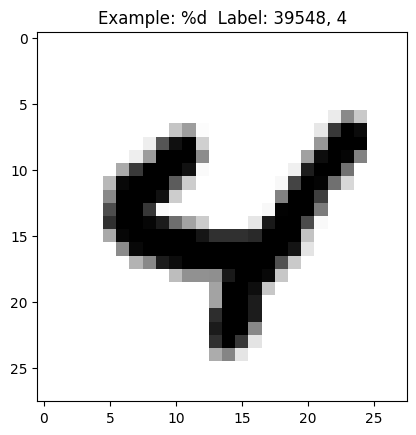

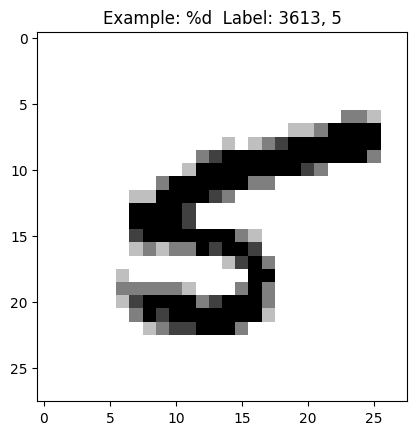

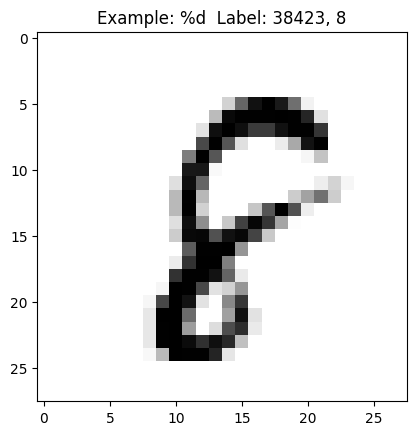

In [3]:
import matplotlib.pyplot as plt
# Función auxiliar para visualizar datos de entrenamiento de manera aleatoria
def display_digit(num,x_train,y_train):
  # Seleccionar la imagen num de mnist.train.images y hacer un reshape al tamaño de la imagen
  image = x_train[num,:,:]
  # Seleccionar el target num de mnist.train.labels
  label = y_train[num]
  # Mostrar
  plt.title(f'Example: %d  Label: {num}, {label}')
  plt.imshow(image, cmap=plt.get_cmap('gray_r'))
  plt.show()

# Mostramos algunos ejemplos
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)

In [4]:
np.random.randint(0, x_train.shape[0])

3104

#### **- Acondicionando el conjunto de datos**

In [5]:
# Pre-procesado obligatorio cuando trabajo con redes neuronales
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train, x_te = x_train / 255.0, x_test / 255.0 #Cambio al rango 0-1 -> Disminuyo CC
y_train = to_categorical(y_train, num_classes=10) #One-hot encoding para minimizar error
print(y_train.shape)
y_te = to_categorical(y_test, num_classes=10)
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42) # 3 subconjuntos es de vital importancia
print(y_tr.shape)
# print(y_tr[0])

(60000, 10)
(54000, 10)


In [6]:
print(y_tr[5214])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [7]:
print(y_tr[5214].argmax(axis=0))

4


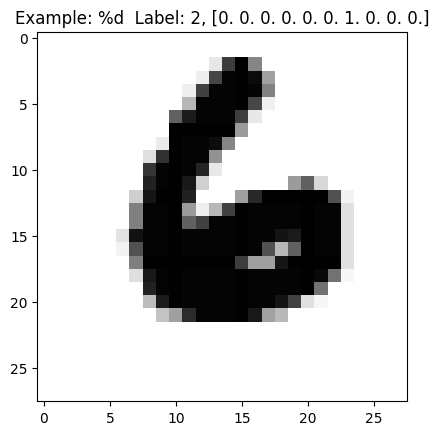

In [8]:
display_digit(2, x_tr,y_tr)

#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.optimizers import SGD

# Definir el modelo secuencial con Input explícito
model = Sequential()
model.add(Input(shape=(28, 28)))       # Definimos la entrada
model.add(Flatten())                   # Aplanamos la matriz 28x28
model.add(Dense(512, activation="relu"))  # Capa oculta
model.add(Dense(10, activation="softmax")) # Capa de salida


In [10]:
#Traigamos nuestro optimizador
from tensorflow.keras.optimizers import SGD
# Ahora que tengo definida la arquitectura, la compilo
model.compile(loss="categorical_crossentropy", optimizer=SGD(0.005), metrics=["accuracy"])

In [11]:
######### Modelo funcional ############ (Clase 04/10/2023)
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

# Definir la entrada
input_layer = Input(shape=(28, 28))
# Capa de aplanamiento
x = Flatten()(input_layer)
x = Dense(512, activation="relu")(x)
# x= Dropout(0.5)(x) Introducción de capa de dropout en un modelo funcional
output_layer = Dense(10, activation="softmax")(x)
# Crear el modelo
model = Model(inputs=input_layer, outputs=output_layer)

In [12]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
# Compilar el modelo
model.compile(
    loss="categorical_crossentropy",
    optimizer=SGD(learning_rate=0.005),
    metrics=["accuracy"]
)

# Entrenar el modelo
print("[INFO]: Entrenando red neuronal...")
H = model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=128
)


[INFO]: Entrenando red neuronal...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6591 - loss: 1.5338 - val_accuracy: 0.8097 - val_loss: 1.0087
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8349 - loss: 0.8039 - val_accuracy: 0.8500 - val_loss: 0.6675
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8607 - loss: 0.5976 - val_accuracy: 0.8700 - val_loss: 0.5410
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8739 - loss: 0.5080 - val_accuracy: 0.8812 - val_loss: 0.4760
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8820 - loss: 0.4572 - val_accuracy: 0.8880 - val_loss: 0.4354
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8881 - loss: 0.4235 - val_accuracy: 0.8935 - val_loss: 0.4068
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8926 - loss: 0.3995 - val_accuracy: 0.8990 - val_loss: 0.3852
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0

#### **- Observando el proceso de entrenamiento para tomar decisiones**

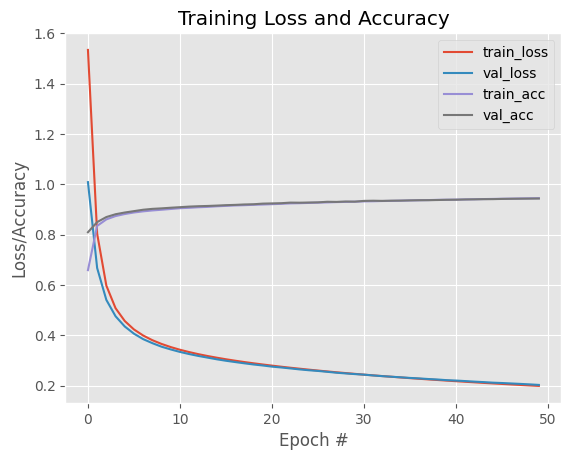

In [14]:
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [15]:
from sklearn.metrics import classification_report
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
predictions = model.predict(x_te, batch_size=128)
print(y_te[0])
print(predictions[0])
print(classification_report(y_te.argmax(axis=1), predictions.argmax(axis=1)))

[INFO]: Evaluando red neuronal...
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[8.4445594e-05 4.0906468e-07 2.9048210e-04 2.5711302e-03 1.7071155e-06
 3.7396214e-05 2.8934490e-08 9.9655652e-01 1.9232837e-05 4.3868498e-04]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.95      0.92      0.94      1032
           3       0.93      0.95      0.94      1010
           4       0.94      0.95      0.94       982
           5       0.94      0.92      0.93       892
           6       0.94      0.95      0.95       958
           7       0.95      0.93      0.94      1028
           8       0.92      0.93      0.93       974
           9       0.93      0.92      0.93      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94    

In [16]:
predictions[0].argmax(axis=0)

np.int64(7)

In [17]:
y_te[0].argmax(axis=0)

np.int64(7)

In [18]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,052 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


--------------------------------------------------------------------------

## **MLP APLICADO A TEXTO: EJEMPLO REUTERS**

#### **- Cargando el conjunto de datos**

In [19]:
import numpy as np
import tensorflow as tf
# Importamos el dataset REUTERS y cargamos los datos
reuters = tf.keras.datasets.reuters
WORD_LIMIT = 10000
(training_data, training_labels), (testing_data, testing_labels) = reuters.load_data(num_words=WORD_LIMIT)
print(training_data.shape)
print(training_labels.shape)
print(testing_data.shape)
print(testing_labels.shape)

C:\Users\maicc\anaconda3\envs\Machine2\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


(8982,)
(8982,)
(2246,)
(2246,)


#### **- Inspeccionando el conjunto de datos**

In [20]:
# Los datos son numericos para decodificarlos, se puede usar reuters.get_word_index()
word_index = reuters.get_word_index()
reverse_word_index = dict({value : key for key, value in word_index.items()})
decoded = ' '.join(
    [reverse_word_index.get(i-3,'?') for i in training_data[5]]
)
decoded

"? the u s agriculture department estimated canada's 1986 87 wheat crop at 31 85 mln tonnes vs 31 85 mln tonnes last month it estimated 1985 86 output at 24 25 mln tonnes vs 24 25 mln last month canadian 1986 87 coarse grain production is projected at 27 62 mln tonnes vs 27 62 mln tonnes last month production in 1985 86 is estimated at 24 95 mln tonnes vs 24 95 mln last month canadian wheat exports in 1986 87 are forecast at 19 00 mln tonnes vs 18 00 mln tonnes last month exports in 1985 86 are estimated at 17 71 mln tonnes vs 17 72 mln last month reuter 3"

#### **- Acondicionando el conjunto de datos**

In [21]:
# Función auxiliar para representar las palabras (que no entiende nuestra red neuronal) en números
import numpy as np
# one hot encoding del input, vector con cada indice indicando si una palabra esta presente
def one_hot_encode(data):
    encoded = np.zeros((len(data),WORD_LIMIT))
    for i, v in enumerate(data):
        encoded[i,v] = 1 # localiza las columnas del genero correspondiente, marca con 1
    return encoded

In [22]:
# Convertimos nuestras palabras a números
x_train = one_hot_encode(training_data)
x_test = one_hot_encode(testing_data)
print(x_train.shape)
print(x_test.shape)

(8982, 10000)
(2246, 10000)


In [23]:
print(x_test[3])

[0. 1. 1. ... 0. 0. 0.]


In [24]:
# Convertimos nuestros labels (categoría reseña) a one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(training_labels)
y_test = to_categorical(testing_labels)
print(y_train.shape)
print(y_test.shape)

(8982, 46)
(2246, 46)


In [25]:
print(y_test[3])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Vamos a codificar la topología de nuestro MLP
model = Sequential()
model.add(Dense(128,activation='relu',input_shape=(WORD_LIMIT,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes
# En el caso de regresión cambiamos la ultima capa por:
#model.add(Dense(1,activation='sigmoid'))

C:\Users\maicc\anaconda3\envs\Machine2\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# Ahora que tengo definida la arquitectura, la compilo
model.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase/ para regresion (mse/mae)
               metrics=['accuracy'])

In [28]:
# A entrenar nuestra red neuronal sea dicho!
H = model.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.6880 - loss: 1.4927 - val_accuracy: 0.7858 - val_loss: 0.9803
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8736 - loss: 0.5676 - val_accuracy: 0.8080 - val_loss: 0.8578
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9386 - loss: 0.2835 - val_accuracy: 0.8052 - val_loss: 0.8966
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9555 - loss: 0.1960 - val_accuracy: 0.8024 - val_loss: 0.9045
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9570 - loss: 0.1658 - val_accuracy: 0.8058 - val_loss: 0.8989
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9588 - loss: 0.1430 - val_accuracy: 0.7935 - val_loss: 0.9468
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9587 - loss: 0.1283 - val_accuracy: 0.7908 - val_loss: 1.0202
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9609 - loss: 0.1186 - val_a

#### **- Observando el proceso de entrenamiento para tomar decisiones**

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,874,124 (14.78 MB)

 Trainable params: 1,291,374 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,582,750 (9.85 MB)

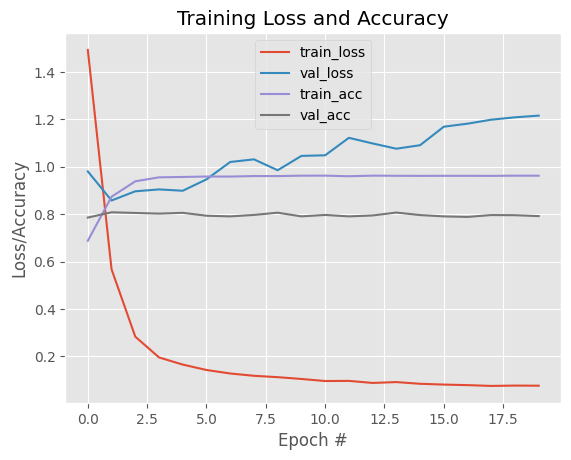

In [30]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [31]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model.predict(x_test)
loss, accuracy = model.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7876 - loss: 1.2863
Loss 1.2863229513168335, accuracy 0.7876224517822266


## **REGULARIZACIÓN EN APRENDIZAJE PROFUNDO**

#### **- Weight regularization L1/L2**

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
# Vamos a codificar la topología de nuestro MLP
model_reg = Sequential()
model_reg.add(Dense(128,activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(WORD_LIMIT,)))
model_reg.add(Dense(64,activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_reg.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\maicc\anaconda3\envs\Machine2\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# Ahora que tengo definida la arquitectura, la compilo
model_reg.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [34]:
# A entrenar nuestra red neuronal sea dicho!
H = model_reg.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.6419 - loss: 2.4040 - val_accuracy: 0.7129 - val_loss: 1.8094
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.7365 - loss: 1.6994 - val_accuracy: 0.7334 - val_loss: 1.6598
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.7581 - loss: 1.5821 - val_accuracy: 0.7423 - val_loss: 1.6023
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.7662 - loss: 1.5266 - val_accuracy: 0.7602 - val_loss: 1.5965
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7773 - loss: 1.4861 - val_accuracy: 0.7602 - val_loss: 1.5425
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.7836 - loss: 1.4598 - val_accuracy: 0.7702 - val_loss: 1.5713
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.7925 - loss: 1.4131 - val_accuracy: 0.7735 - val_loss: 1.5550
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7954 - loss: 1.3921 - val_

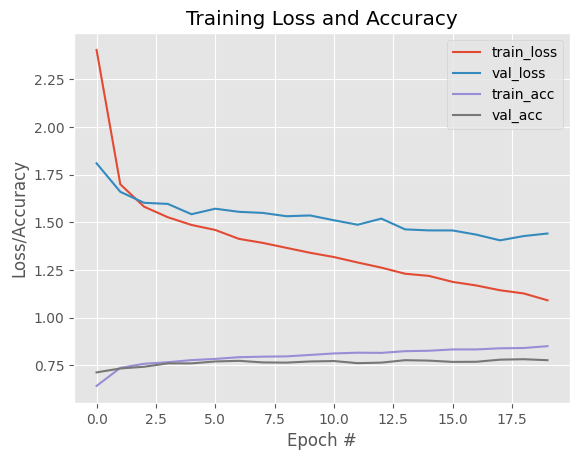

In [35]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [36]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_reg.predict(x_test)
loss, accuracy = model_reg.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7627 - loss: 1.4639
Loss 1.4638590812683105, accuracy 0.7626892328262329


#### **- Dropout**

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
# Vamos a codificar la topología de nuestro MLP
model_drop = Sequential()
model_drop.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(64,activation='relu'))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\maicc\anaconda3\envs\Machine2\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
# Ahora que tengo definida la arquitectura, la compilo
model_drop.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [39]:
# A entrenar nuestra red neuronal sea dicho!
H = model_drop.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.5275 - loss: 2.0377 - val_accuracy: 0.7062 - val_loss: 1.3188
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6834 - loss: 1.3491 - val_accuracy: 0.7329 - val_loss: 1.1503
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7299 - loss: 1.1184 - val_accuracy: 0.7624 - val_loss: 1.0623
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7705 - loss: 0.9435 - val_accuracy: 0.7835 - val_loss: 1.0339
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.7950 - loss: 0.8453 - val_accuracy: 0.7885 - val_loss: 1.0178
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8152 - loss: 0.7548 - val_accuracy: 0.7974 - val_loss: 0.9997
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.8234 - loss: 0.6842 - val_accuracy: 0.7974 - val_loss: 1.0356
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8367 - loss: 0.6351 - val_acc

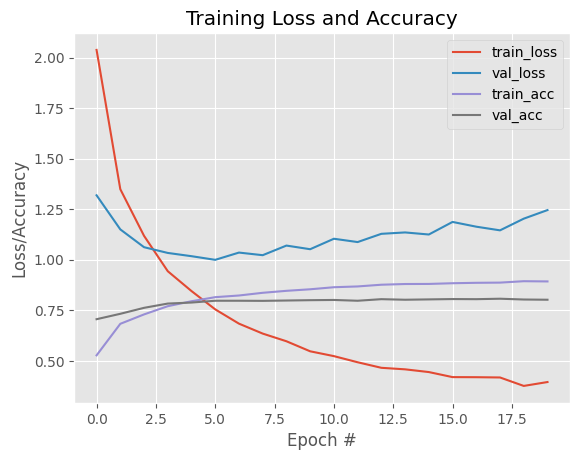

In [40]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

# ¿Y si desconectamos mayor porcentaje de neuronas?

In [41]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_drop.predict(x_test)
loss, accuracy = model_drop.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7934 - loss: 1.3782
Loss 1.3782076835632324, accuracy 0.7934104800224304


#### **- Batch Normalization**

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
# Vamos a codificar la topología de nuestro MLP
model_bn = Sequential()
model_bn.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(64,activation='relu'))


model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\maicc\anaconda3\envs\Machine2\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
# Ahora que tengo definida la arquitectura, la compilo
model_bn.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [44]:
# A entrenar nuestra red neuronal sea dicho!
H = model_bn.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.4653 - loss: 2.5704 - val_accuracy: 0.7078 - val_loss: 1.6680
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6676 - loss: 1.5510 - val_accuracy: 0.7501 - val_loss: 1.1958
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7125 - loss: 1.2796 - val_accuracy: 0.7668 - val_loss: 1.1087
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7464 - loss: 1.1102 - val_accuracy: 0.7774 - val_loss: 1.0432
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7688 - loss: 0.9874 - val_accuracy: 0.7830 - val_loss: 1.0059
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7852 - loss: 0.8908 - val_accuracy: 0.7913 - val_loss: 0.9842
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7990 - loss: 0.8306 - val_accuracy: 0.7958 - val_loss: 0.9653
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8118 - loss: 0.7779 - val_acc

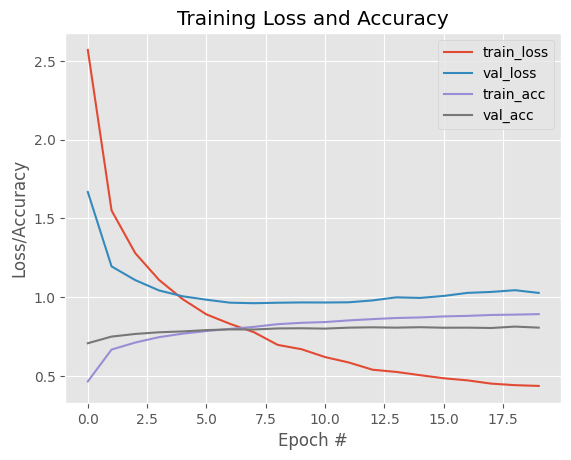

In [45]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [46]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_bn.predict(x_test)
loss, accuracy = model_bn.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7939 - loss: 1.0840
Loss 1.0839506387710571, accuracy 0.7938557267189026


### **Trabajo En Casa**

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
# Modelo de red neuronal
from sklearn.neural_network import MLPClassifier

# Métricas para evaluar si el modelo aprendió
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Librerías para procesamiento de imágenes
from skimage import io, color
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes
from skimage.measure import label, regionprops
from skimage.transform import resize

In [82]:
# Cargamos el dataset de dígitos incluido en sklearn
digits = load_digits()

# X contiene las imágenes convertidas en vectores
X = digits.data

# y contiene la etiqueta real de cada imagen (0,1,2,...,9)
y = digits.target

# Mostramos la forma del dataset
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (1797, 64)
Forma de y: (1797,)


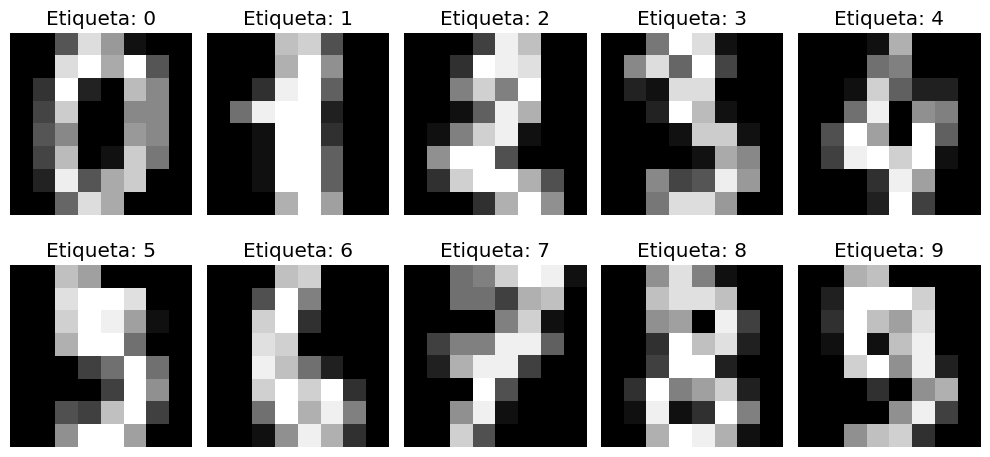

In [83]:
# MOSTRAR ALGUNOS DÍGITOS DEL DATASET

# Creamos una figura para mostrar 10 ejemplos
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Recorremos los primeros 10 dígitos
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Etiqueta: {digits.target[i]}")
    ax.axis("off")

# Ajustamos la visualización
plt.tight_layout()
plt.show()

In [84]:
# DIVIDIR DATOS

# Separamos el dataset en entrenamiento y prueba
# 80% para entrenar y 20% para probar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Mostramos tamaños
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (1437, 64)
Datos de prueba: (360, 64)


In [85]:
# CREAR Y ENTRENAR EL MODELO

# Creamos una red neuronal multicapa
# hidden_layer_sizes indica el tamaño de las capas ocultas
modelo = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42
)

# Entrenamos el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

# Mensaje de confirmación
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [86]:
# EVALUAR SI EL AGENTE APRENDIÓ

# El modelo predice las etiquetas del conjunto de prueba
y_pred = modelo.predict(X_test)

# Calculamos la precisión
precision = accuracy_score(y_test, y_pred)

# Mostramos el resultado
print("Precisión del modelo:", precision)

# Mostramos un reporte más detallado
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))

Precisión del modelo: 0.9666666666666667

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.90      0.97      0.93        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.94      0.97        36
           7       1.00      1.00      1.00        36
           8       0.97      0.83      0.89        35
           9       0.95      0.97      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



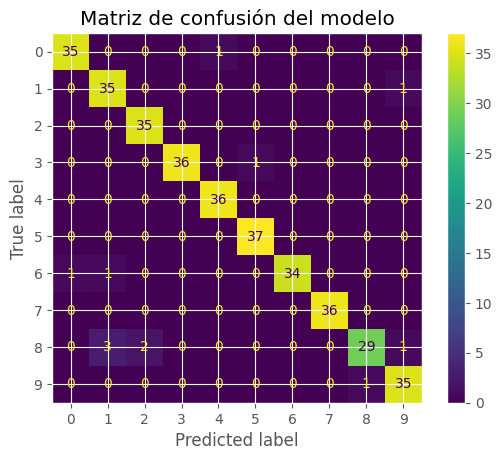

In [87]:
# CELDA 7: MATRIZ DE CONFUSIÓN

# Mostramos la matriz de confusión para ver cómo clasifica el modelo
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

# Título del gráfico
plt.title("Matriz de confusión del modelo")
plt.show()

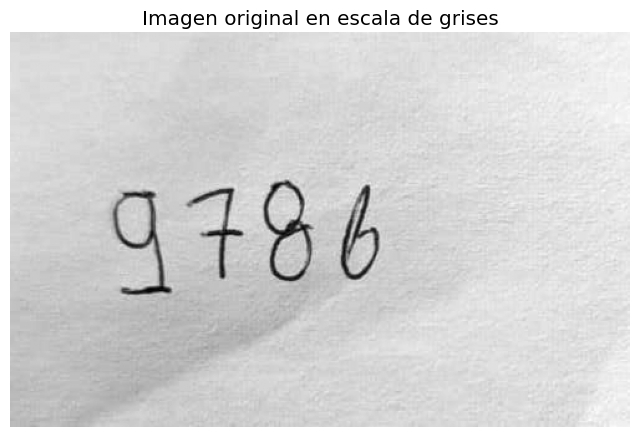

In [90]:
# CARGAR LA FOTO DE LA HOJA

# Cambia el nombre si tu imagen se llama diferente
ruta_imagen = "numeros.PNG"

# Leemos la imagen
imagen = io.imread(ruta_imagen)

# Si la imagen tiene 3 canales (RGB), la convertimos a gris
if len(imagen.shape) == 3:
    gris = color.rgb2gray(imagen)
else:
    gris = imagen

# Mostramos la imagen en escala de grises
plt.figure(figsize=(8, 6))
plt.imshow(gris, cmap="gray")
plt.title("Imagen original en escala de grises")
plt.axis("off")
plt.show()

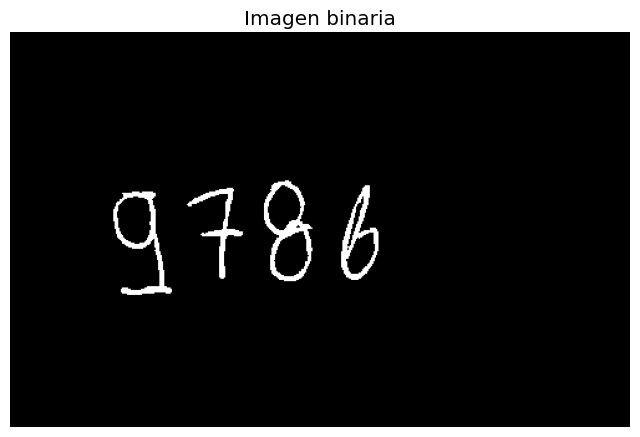

Umbral calculado: 0.3681402657781863


In [91]:
# BINARIZAR LA IMAGEN

# Calculamos automáticamente un umbral
umbral = threshold_otsu(gris)

# Convertimos la imagen a blanco y negro
# Aquí asumimos que los números son oscuros y el fondo claro
binaria = gris < umbral

# Mostramos la imagen binaria
plt.figure(figsize=(8, 6))
plt.imshow(binaria, cmap="gray")
plt.title("Imagen binaria")
plt.axis("off")
plt.show()

# Mostramos el valor del umbral por si lo necesitas
print("Umbral calculado:", umbral)

C:\Users\maicc\AppData\Local\Temp\ipykernel_840\618485611.py:4: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binaria_limpia = remove_small_objects(binaria, min_size=30)
C:\Users\maicc\AppData\Local\Temp\ipykernel_840\618485611.py:7: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binaria_limpia = remove_small_

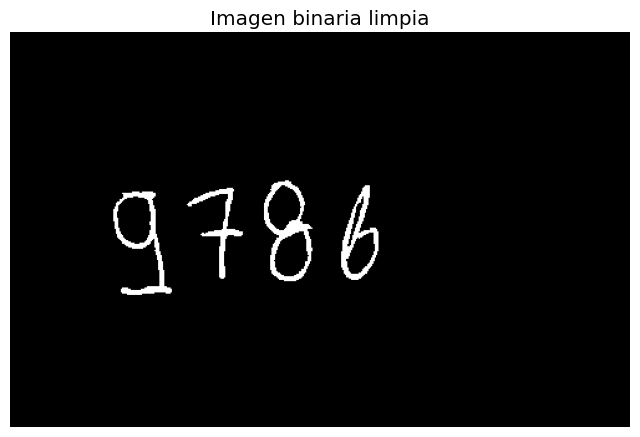

In [92]:
# LIMPIAR RUIDO

# Eliminamos pequeños objetos que pueden ser ruido
binaria_limpia = remove_small_objects(binaria, min_size=30)

# Cerramos pequeños huecos dentro de los objetos
binaria_limpia = remove_small_holes(binaria_limpia, area_threshold=20)

# Mostramos la imagen limpia
plt.figure(figsize=(8, 6))
plt.imshow(binaria_limpia, cmap="gray")
plt.title("Imagen binaria limpia")
plt.axis("off")
plt.show()

Total de regiones detectadas: 4


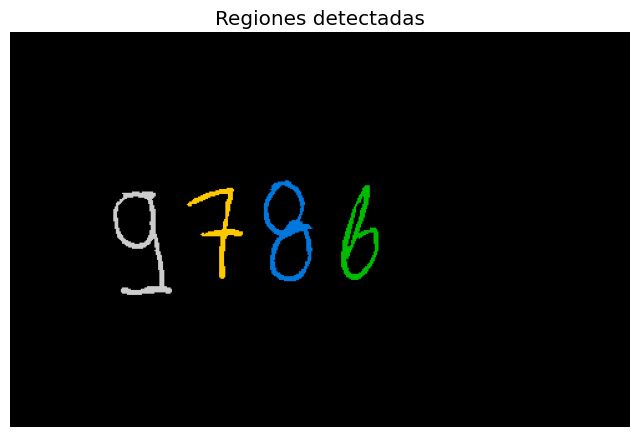

In [93]:
# DETECTAR REGIONES

# Etiquetamos las regiones conectadas
etiquetas = label(binaria_limpia)

# Obtenemos las propiedades de cada región detectada
regiones = regionprops(etiquetas)

# Mostramos cuántas regiones detectó
print("Total de regiones detectadas:", len(regiones))

# Mostramos las regiones con colores distintos
plt.figure(figsize=(8, 6))
plt.imshow(etiquetas, cmap="nipy_spectral")
plt.title("Regiones detectadas")
plt.axis("off")
plt.show()

In [94]:
# EXTRAER CADA NÚMERO

# Lista donde se guardarán las imágenes de los dígitos recortados
digitos_recortados = []

# Lista donde se guardarán las cajas de cada dígito
cajas = []

# Recorremos cada región detectada
for region in regiones:
    
    # Extraemos las coordenadas de la caja delimitadora
    minr, minc, maxr, maxc = region.bbox
    
    # Filtramos regiones muy pequeñas para evitar ruido
    if region.area > 50:
        
        # Recortamos el dígito de la imagen limpia
        recorte = binaria_limpia[minr:maxr, minc:maxc]
        
        # Redimensionamos a 8x8 para que coincida con el dataset de entrenamiento
        recorte_8x8 = resize(recorte.astype(float), (8, 8), anti_aliasing=True)
        
        # Invertimos la imagen si hace falta para que se parezca al formato del dataset
        recorte_8x8 = 1 - recorte_8x8
        
        # Escalamos valores al rango parecido al dataset de sklearn (0 a 16)
        recorte_8x8 = recorte_8x8 * 16
        
        # Guardamos el dígito procesado
        digitos_recortados.append(recorte_8x8)
        
        # Guardamos la caja de la región
        cajas.append((minr, minc, maxr, maxc))

# Mostramos cuántos dígitos útiles se encontraron
print("Dígitos útiles encontrados:", len(digitos_recortados))

Dígitos útiles encontrados: 4


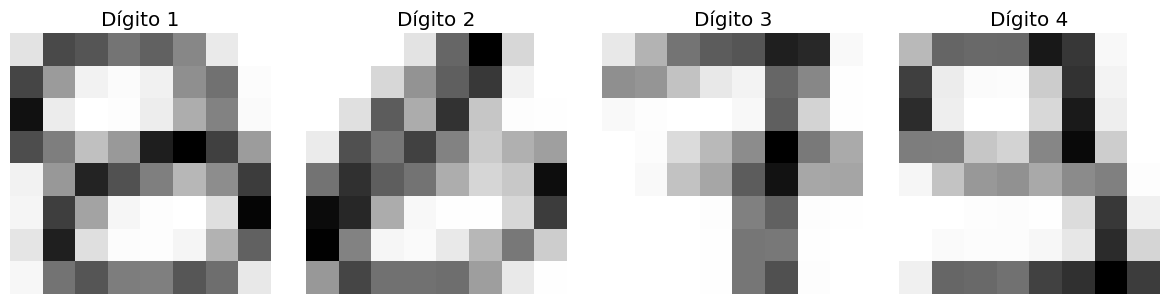

In [95]:
# MOSTRAR LOS DÍGITOS RECORTADOS

# Verificamos si encontró al menos un dígito
if len(digitos_recortados) > 0:
    
    # Creamos una figura para mostrar todos los dígitos encontrados
    fig, axes = plt.subplots(1, len(digitos_recortados), figsize=(12, 3))
    
    # Si solo hay un dígito, convertimos axes en lista
    if len(digitos_recortados) == 1:
        axes = [axes]
    
    # Mostramos cada dígito
    for i, ax in enumerate(axes):
        ax.imshow(digitos_recortados[i], cmap="gray")
        ax.set_title(f"Dígito {i+1}")
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

else:
    print("No se detectaron dígitos. Revisa la foto o el umbral.")

In [96]:
# PREPARAR DATOS PARA PREDECIR

# Verificamos si hay dígitos recortados
if len(digitos_recortados) > 0:
    
    # Convertimos cada imagen 8x8 en un vector de 64 valores
    X_nuevos = np.array([img.flatten() for img in digitos_recortados])
    
    # Mostramos la forma del arreglo
    print("Forma de X_nuevos:", X_nuevos.shape)

else:
    print("No hay dígitos para convertir.")

Forma de X_nuevos: (4, 64)


In [97]:
# PREDECIR LOS NÚMEROS DE LA FOTO

# Verificamos si existe X_nuevos
if len(digitos_recortados) > 0:
    
    # El modelo predice qué número es cada recorte
    predicciones = modelo.predict(X_nuevos)
    
    # Mostramos el resultado
    print("Predicciones:", predicciones)

else:
    print("No se pudo predecir porque no hay dígitos detectados.")

Predicciones: [7 2 2 7]


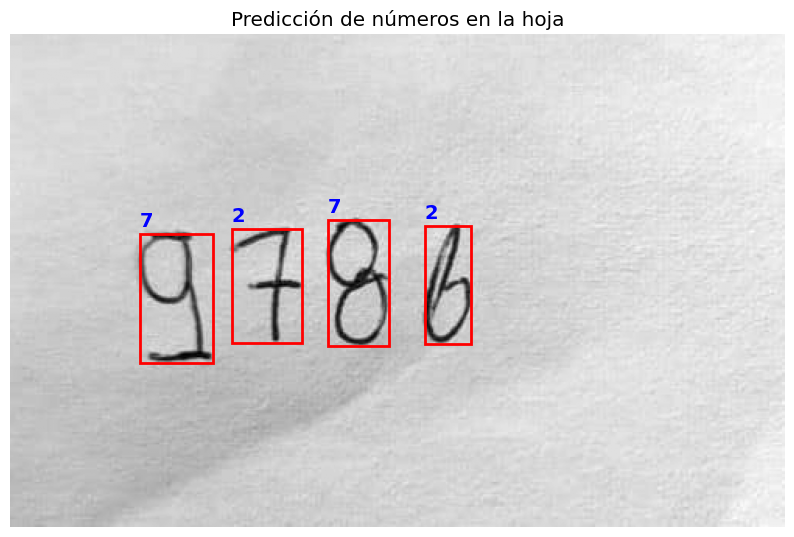

In [98]:
# DIBUJAR RESULTADOS EN LA IMAGEN

# Verificamos que existan cajas y predicciones
if len(digitos_recortados) > 0:
    
    # Creamos la figura
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Mostramos la imagen base
    ax.imshow(gris, cmap="gray")
    ax.set_title("Predicción de números en la hoja")
    ax.axis("off")
    
    # Recorremos cada predicción con su caja correspondiente
    for pred, (minr, minc, maxr, maxc) in zip(predicciones, cajas):
        
        # Dibujamos un rectángulo rojo alrededor del número
        ax.add_patch(
            plt.Rectangle(
                (minc, minr),
                maxc - minc,
                maxr - minr,
                fill=False,
                edgecolor="red",
                linewidth=2
            )
        )
        
        # Escribimos la predicción encima del número
        ax.text(
            minc,
            minr - 5,
            str(pred),
            color="blue",
            fontsize=14,
            weight="bold"
        )
    
    # Mostramos el resultado final
    plt.show()

else:
    print("No hay resultados para dibujar.")

In [99]:
# MOSTRAR CARACTERÍSTICAS DE CADA REGIÓN

# Recorremos las regiones de nuevo
contador = 1

for region in regiones:
    if region.area > 50:
        print(f"Región {contador}")
        print("Área:", region.area)
        print("Perímetro:", region.perimeter)
        print("-" * 30)
        contador += 1

Región 1
Área: 895.0
Perímetro: 438.2325394193525
------------------------------
Región 2
Área: 740.0
Perímetro: 391.9421715174808
------------------------------
Región 3
Área: 565.0
Perímetro: 278.78174593052023
------------------------------
Región 4
Área: 844.0
Perímetro: 422.1431816442575
------------------------------


In [101]:
# PREPARAR DATOS PARA CNN


# Cargar dataset otra vez
digits = load_digits()

X = digits.images   # ← ahora usamos imágenes 8x8
y = digits.target

# Normalizar
X = X / 16.0

# Redimensionar para CNN (agregar canal)
X = X.reshape(-1, 8, 8, 1)

# One-hot encoding
from tensorflow.keras.utils import to_categorical
y_cat = to_categorical(y)

# Dividir datos
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

print("Datos listos para CNN")

Datos listos para CNN


In [102]:
# CREAR CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model_cnn = Sequential()

# Capa convolucional
model_cnn.add(Conv2D(32, (3,3), activation='relu', input_shape=(8,8,1)))

# Pooling
model_cnn.add(MaxPooling2D((2,2)))

# Aplanar
model_cnn.add(Flatten())

# Capa densa
model_cnn.add(Dense(64, activation='relu'))

# Salida
model_cnn.add(Dense(10, activation='softmax'))

# Compilar
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN creada")

CNN creada


C:\Users\maicc\anaconda3\envs\Machine2\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [103]:
# ==============================
# CELDA 11: EVALUAR CNN
# ==============================

loss, acc = model_cnn.evaluate(x_test, y_test)

print("Precisión CNN:", acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0611 - loss: 2.3026
Precisión CNN: 0.06111111119389534


### **Github:** https://github.com/Maick721/MAQUINAS-E-LEARNING-2-.git